# I. Tutorial
## II-1. Prepare a trajectory file

- Download FCC-Al trajectory ($12\times 12 \times 12 \times 4$ atoms) by typing `wget https://zenodo.org/records/10014454/files/dumpT300.NVT.atom.velocity.gz`


## II-2. Compute Sqw \[Cqw\]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import bulk
from dynasor import compute_dynamic_structure_factors, Trajectory
from dynasor.qpoints import get_supercell_qpoints_along_path
from seekpath import get_path

/home/wyz/venvpy/shellpy-regular/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
trajectory_filename = 'dumpT300.NVT.atom.velocity.gz'
traj = Trajectory(trajectory_filename,
                  trajectory_format='lammps_internal', frame_stop=10000)

INFO 2025-08-12 10:00:40: Trajectory file: dumpT300.NVT.atom.velocity.gz
INFO 2025-08-12 10:00:40: Total number of particles: 6912
INFO 2025-08-12 10:00:40: Number of atom types: 1
INFO 2025-08-12 10:00:40: Number of atoms of type X: 6912
INFO 2025-08-12 10:00:40: Simulation cell (in Angstrom):
[[48.78  0.    0.  ]
 [ 0.   48.78  0.  ]
 [ 0.    0.   48.78]]


In [3]:
display(traj)

Field,Value
File name,dumpT300.NVT.atom.velocity.gz
Number of atoms,6912
Cell metric,[[48.78 0. 0. ] [ 0. 48.78 0. ] [ 0. 0. 48.78]]
Frame step,1
Atom types,['X']


In [4]:
print(traj)

Trajectory
filename     : dumpT300.NVT.atom.velocity.gz
natoms       : 6912
frame_start  : 0
frame_stop   : 10000
frame_step   : 1
frame_index  : 0
cell         : [[48.78  0.    0.  ]
                [ 0.   48.78  0.  ]
                [ 0.    0.   48.78]]


In [15]:
prim = bulk('Al', a=4.065)
path_info = get_path((
    prim.cell,
    prim.get_scaled_positions(),
    prim.numbers))
point_coordinates = path_info['point_coords']
path = path_info['path']
#q_points_prim=path_info['q_points']
display(prim.cell)
display(point_coordinates)
display(path)


Cell([[0.0, 2.0325, 2.0325], [2.0325, 0.0, 2.0325], [2.0325, 2.0325, 0.0]])

{'GAMMA': [0.0, 0.0, 0.0],
 'X': [0.5, 0.0, 0.5],
 'L': [0.5, 0.5, 0.5],
 'W': [0.5, 0.25, 0.75],
 'W_2': [0.75, 0.25, 0.5],
 'K': [0.375, 0.375, 0.75],
 'U': [0.625, 0.25, 0.625]}

[('GAMMA', 'X'),
 ('X', 'U'),
 ('K', 'GAMMA'),
 ('GAMMA', 'L'),
 ('L', 'W'),
 ('W', 'X')]

In [6]:
q_segments = get_supercell_qpoints_along_path(
    path, point_coordinates, prim.cell, traj.cell)
q_points = np.vstack(q_segments)

In [7]:
print(q_segments)

[array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-3.57510096e-18,  1.28806587e-01,  3.57510096e-18],
       [-7.15020192e-18,  2.57613174e-01,  7.15020192e-18],
       [ 0.00000000e+00,  3.86419761e-01,  0.00000000e+00],
       [-1.43004038e-17,  5.15226347e-01,  1.43004038e-17],
       [ 1.43004038e-17,  6.44032934e-01, -1.43004038e-17],
       [ 0.00000000e+00,  7.72839521e-01,  0.00000000e+00],
       [-2.69103435e-17,  9.01646108e-01,  2.69103435e-17],
       [-2.86008077e-17,  1.03045269e+00,  2.86008077e-17],
       [ 0.00000000e+00,  1.15925928e+00,  0.00000000e+00],
       [ 2.86008077e-17,  1.28806587e+00, -2.86008077e-17],
       [-2.86008077e-17,  1.41687246e+00,  2.86008077e-17],
       [ 0.00000000e+00,  1.54567904e+00,  0.00000000e+00]]), array([[0.        , 1.54567904, 0.        ],
       [0.12880659, 1.54567904, 0.12880659],
       [0.25761317, 1.54567904, 0.25761317],
       [0.38641976, 1.54567904, 0.38641976]]), array([[ 1.15925928e+00,  1.1592592

In [8]:
print(q_points)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-3.57510096e-18  1.28806587e-01  3.57510096e-18]
 [-7.15020192e-18  2.57613174e-01  7.15020192e-18]
 [ 0.00000000e+00  3.86419761e-01  0.00000000e+00]
 [-1.43004038e-17  5.15226347e-01  1.43004038e-17]
 [ 1.43004038e-17  6.44032934e-01 -1.43004038e-17]
 [ 0.00000000e+00  7.72839521e-01  0.00000000e+00]
 [-2.69103435e-17  9.01646108e-01  2.69103435e-17]
 [-2.86008077e-17  1.03045269e+00  2.86008077e-17]
 [ 0.00000000e+00  1.15925928e+00  0.00000000e+00]
 [ 2.86008077e-17  1.28806587e+00 -2.86008077e-17]
 [-2.86008077e-17  1.41687246e+00  2.86008077e-17]
 [ 0.00000000e+00  1.54567904e+00  0.00000000e+00]
 [ 0.00000000e+00  1.54567904e+00  0.00000000e+00]
 [ 1.28806587e-01  1.54567904e+00  1.28806587e-01]
 [ 2.57613174e-01  1.54567904e+00  2.57613174e-01]
 [ 3.86419761e-01  1.54567904e+00  3.86419761e-01]
 [ 1.15925928e+00  1.15925928e+00  0.00000000e+00]
 [ 1.03045269e+00  1.03045269e+00  5.72016154e-17]
 [ 9.01646108e-01  9.01646108e-

In [9]:
len(q_points)

48

In [10]:
q_points.shape


(48, 3)

In [11]:
%%time
sample = compute_dynamic_structure_factors(
    traj, q_points, dt=25.0, window_size=500,
    window_step=50, calculate_currents=True)


INFO 2025-08-12 10:00:41: Spacing between samples (frame_step): 1
INFO 2025-08-12 10:00:41: Time between consecutive frames in input trajectory (dt): 25.0 fs
INFO 2025-08-12 10:00:41: Time between consecutive frames used (dt * frame_step): 25.0 fs
INFO 2025-08-12 10:00:41: Time window size (dt * frame_step * window_size): 12500.0 fs
INFO 2025-08-12 10:00:41: Angular frequency resolution: dw = 0.000251 rad/fs = 0.165 meV
INFO 2025-08-12 10:00:41: Maximum angular frequency (dw * window_size): 0.125664 rad/fs = 82.713 meV
INFO 2025-08-12 10:00:41: Nyquist angular frequency (2pi / frame_step / dt / 2): 0.125664 rad/fs = 82.713 meV
INFO 2025-08-12 10:00:41: Calculating current (velocity) correlations
INFO 2025-08-12 10:00:41: Number of q-points: 48
INFO 2025-08-12 10:00:49: Processing window 0 to 500
INFO 2025-08-12 10:01:06: Processing window 1000 to 1500
INFO 2025-08-12 10:01:22: Processing window 2000 to 2500
INFO 2025-08-12 10:01:39: Processing window 3000 to 3500
INFO 2025-08-12 10:01:

In [16]:
display(sample)

Field,Content/Size
Atom types,['X']
Pairs,"[('X', 'X')]"
Particle counts,{'X': 6912}
Simulations cell,[[48.78 0. 0. ] [ 0. 48.78 0. ] [ 0. 0. 48.78]]
q_points,"(48, 3)"
time,"(501,)"
omega,"(501,)"
Fqt_coh_X_X,"(48, 501)"
Sqw_coh_X_X,"(48, 501)"
Fqt_coh,"(48, 501)"


In [18]:
print(sample.time)

[    0.    25.    50.    75.   100.   125.   150.   175.   200.   225.
   250.   275.   300.   325.   350.   375.   400.   425.   450.   475.
   500.   525.   550.   575.   600.   625.   650.   675.   700.   725.
   750.   775.   800.   825.   850.   875.   900.   925.   950.   975.
  1000.  1025.  1050.  1075.  1100.  1125.  1150.  1175.  1200.  1225.
  1250.  1275.  1300.  1325.  1350.  1375.  1400.  1425.  1450.  1475.
  1500.  1525.  1550.  1575.  1600.  1625.  1650.  1675.  1700.  1725.
  1750.  1775.  1800.  1825.  1850.  1875.  1900.  1925.  1950.  1975.
  2000.  2025.  2050.  2075.  2100.  2125.  2150.  2175.  2200.  2225.
  2250.  2275.  2300.  2325.  2350.  2375.  2400.  2425.  2450.  2475.
  2500.  2525.  2550.  2575.  2600.  2625.  2650.  2675.  2700.  2725.
  2750.  2775.  2800.  2825.  2850.  2875.  2900.  2925.  2950.  2975.
  3000.  3025.  3050.  3075.  3100.  3125.  3150.  3175.  3200.  3225.
  3250.  3275.  3300.  3325.  3350.  3375.  3400.  3425.  3450.  3475.
  3500

In [19]:
sample.available_correlation_functions


['Clqt',
 'Clqt_X_X',
 'Clqw',
 'Clqw_X_X',
 'Ctqt',
 'Ctqt_X_X',
 'Ctqw',
 'Ctqw_X_X',
 'Fqt_coh',
 'Fqt_coh_X_X',
 'Sqw_coh',
 'Sqw_coh_X_X']

In [21]:
sample.write_to_npz('my_sample.npz')


## II-3. Plotting

In [22]:
q_distances = []
q_labels = dict()

# starting point
qr = 0.0

# collect labels and q-distances along the entire q-point path
for it, q_segment in enumerate(q_segments):
    q_distances.append(qr)
    q_labels[qr] = path[it][0]
    for qi, qj in zip(q_segment[1:], q_segment[:-1]):
        qr += np.linalg.norm(qi - qj)
        q_distances.append(qr)

q_labels[qr] = path[-1][1]
q_distances = np.array(q_distances)



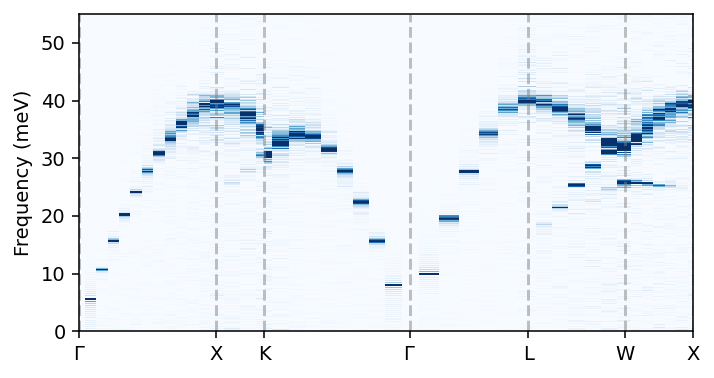

In [23]:
from dynasor.units import radians_per_fs_to_meV as conversion_factor

fig = plt.figure(figsize=(5.2, 2.8), dpi=140)
ax = fig.add_subplot(111)
ax.pcolormesh(q_distances, conversion_factor * sample.omega,
              sample.Sqw_coh.T, cmap='Blues', vmin=0, vmax=4)

xticks = []
xticklabels = []
for q_dist, q_label in q_labels.items():
    ax.axvline(q_dist, c='0.5', alpha=0.5, ls='--')
    xticks.append(q_dist)
    xticklabels.append(q_label.replace('GAMMA', r'$\Gamma$'))

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

ax.set_xlim([0, q_distances.max()])
ax.set_ylim([0, 55])

ax.set_ylabel('Frequency (meV)')

fig.tight_layout()



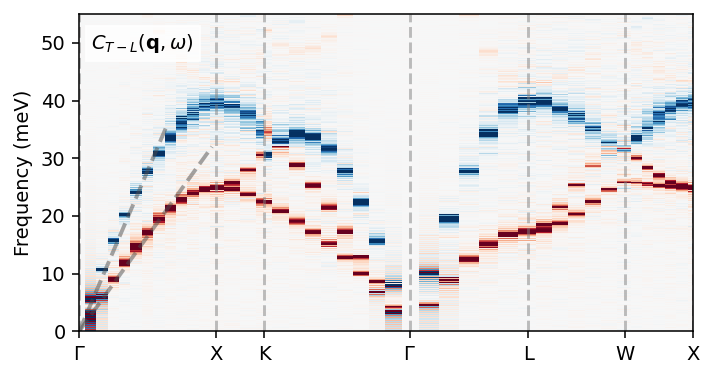

In [24]:
fig = plt.figure(figsize=(5.2, 2.8), dpi=140)
ax = fig.add_subplot(111)
ax.pcolormesh(q_distances, conversion_factor * sample.omega,
              sample.Clqw.T - sample.Ctqw.T,
              cmap='RdBu', vmin=-6000, vmax=6000)

ax.plot([0, 1.0], [0, 36], alpha=0.5, ls='--', c='0.3', lw=2)
ax.plot([0, 1.5], [0, 32], alpha=0.5, ls='--', c='0.3', lw=2)

ax.text(0.02, 0.89, r'$C_{T-L}(\mathbf{q}, \omega)$', transform=ax.transAxes,
        bbox={'color': 'white', 'alpha': 0.8, 'pad': 3})

xticks = []
xticklabels = []
for q_dist, q_label in q_labels.items():
    ax.axvline(q_dist, c='0.5', alpha=0.5, ls='--')
    xticks.append(q_dist)
    xticklabels.append(q_label.replace('GAMMA', r'$\Gamma$'))

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

ax.set_xlim([0, q_distances.max()])
ax.set_ylim([0, 55])

ax.set_ylabel('Frequency (meV)')

fig.tight_layout()

